In [13]:
!pip install confluent-kafka

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ------- -------------------------------- 0.8/4.1 MB 6.6 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 9.1 MB/s  0:00:00


## Populated a new Version (V6) with 3 years of Historical Data

This was to experiment and check how the newly added features impact model performance

In [1]:
import sys
import os
import pandas as pd
import hopsworks
import requests
from datetime import datetime, timedelta
from dotenv import load_dotenv

sys.path.append(os.path.abspath('..')) 
from src.config import GLOBAL_CITIES
from src.feature_pipeline.compute_features import build_feature_pipeline

print("1. Fetching 3 years of RAW data using the deep-history Archive API...")

# --- TEMPORARY DEEP-HISTORY FETCHER ---
def fetch_deep_history(city_name, start_date_str, end_date_str):
    # 1. Get Coordinates
    coord_url = f"https://geocoding-api.open-meteo.com/v1/search?name={city_name}&count=1&format=json"
    coords = requests.get(coord_url).json()["results"][0]
    lat, lon = coords["latitude"], coords["longitude"]

    # 2. AQI API (Supports deep history natively)
    url_aqi = (f"https://air-quality-api.open-meteo.com/v1/air-quality?"
               f"latitude={lat}&longitude={lon}&start_date={start_date_str}&end_date={end_date_str}"
               f"&hourly=pm10,pm2_5,nitrogen_dioxide,ozone")
    
    data_aqi = requests.get(url_aqi).json().get("hourly", {})
    df_aqi = pd.DataFrame({
        "timestamp": pd.to_datetime(data_aqi.get("time", [])),
        "pm10": data_aqi.get("pm10", []), "pm2_5": data_aqi.get("pm2_5", []),
        "no2": data_aqi.get("nitrogen_dioxide", []), "ozone": data_aqi.get("ozone", [])
    })

    # 3. WEATHER ARCHIVE API (Bypasses the 90-day forecast limit)
    url_weather = (f"https://archive-api.open-meteo.com/v1/archive?"
                   f"latitude={lat}&longitude={lon}&start_date={start_date_str}&end_date={end_date_str}"
                   f"&hourly=temperature_2m,precipitation,wind_speed_10m")
    
    data_weather = requests.get(url_weather).json().get("hourly", {})
    df_weather = pd.DataFrame({
        "timestamp": pd.to_datetime(data_weather.get("time", [])),
        "temperature_2m": data_weather.get("temperature_2m", []),
        "precipitation": data_weather.get("precipitation", []),
        "wind_speed_10m": data_weather.get("wind_speed_10m", [])
    })

    df_master = pd.merge(df_aqi, df_weather, on="timestamp", how="inner")
    df_master['city'] = city_name
    return df_master.dropna().reset_index(drop=True)

# Loop cities and fetch
data_frames = []
for city in GLOBAL_CITIES:
    print(f"  -> Pulling archive data for {city.capitalize()}...")
    # Using a 3-year window that stops slightly before today (Archive API has a ~5 day lag)
    data_frames.append(fetch_deep_history(city, "2023-05-01", "2026-05-01"))

raw_history_df = pd.concat(data_frames, ignore_index=True)
print(f"Success! Fetched {len(raw_history_df)} historical hourly rows.\n")

print("2. Running the new smart feature engineering...")

# --- TEMPORARY PIPELINE OVERRIDE (Stops the incremental 2-day slice) ---
def backfill_pipeline(raw_df):
    aggregation_rules = {
        'pm2_5': ['mean', 'max', 'std'], 'pm10': ['mean', 'max'], 'no2': ['mean'],
        'ozone': ['mean', 'max'], 'temperature_2m': ['mean', 'max', 'min'],
        'precipitation': ['sum'], 'wind_speed_10m': ['mean', 'max']
    }
    
    df = raw_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['date'] = df['timestamp'].dt.date
    
    daily_df = df.groupby(['city', 'date']).agg(aggregation_rules).reset_index()
    daily_df.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in daily_df.columns]
    daily_df = daily_df.rename(columns={'pm2_5_mean': 'pm2_5'})
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    daily_df = daily_df.sort_values(by=['city', 'date']).reset_index(drop=True).fillna(0)
    
    daily_df['month'] = daily_df['date'].dt.month
    daily_df['day_of_week'] = daily_df['date'].dt.dayofweek
    daily_df['day_of_year'] = daily_df['date'].dt.dayofyear
    
    daily_df['pm2_5_rolling_3d'] = daily_df.groupby('city')['pm2_5'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    daily_df['pm2_5_rolling_7d'] = daily_df.groupby('city')['pm2_5'].transform(lambda x: x.rolling(7, min_periods=1).mean())
    daily_df['pm2_5_change_rate'] = daily_df.groupby('city')['pm2_5'].diff().fillna(0)
    
    daily_df['target_pm2_5_1d'] = daily_df.groupby('city')['pm2_5'].shift(-1)
    daily_df['target_pm2_5_2d'] = daily_df.groupby('city')['pm2_5'].shift(-2)
    daily_df['target_pm2_5_3d'] = daily_df.groupby('city')['pm2_5'].shift(-3)
    
    input_cols = [col for col in daily_df.columns if not col.startswith('target_')]
    final_df = daily_df.dropna(subset=input_cols).reset_index(drop=True)
    
    target_cols = [col for col in daily_df.columns if col.startswith('target_')]
    final_df[target_cols] = final_df[target_cols].fillna(-1.0)
    
    return final_df.drop(columns=['timestamp'], errors='ignore')

full_historical_df = backfill_pipeline(raw_history_df)
print(f"Math complete. Final Backfill Matrix Shape: {full_historical_df.shape}\n")

print("3. Pushing the rescue data to Hopsworks Version 6...")
load_dotenv(os.path.abspath('../.env'))
project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai", 
    api_key_value=os.environ.get("HOPSWORKS_API_KEY")
)
fs = project.get_feature_store()

aqi_fg = fs.get_feature_group("global_aqi_features", version=6)
aqi_fg.insert(full_historical_df)

print("Rescue complete! Version 6 is fully loaded and ready for training.")

1. Fetching 3 years of RAW data using the deep-history Archive API...
  -> Pulling archive data for London...
  -> Pulling archive data for Beijing...
  -> Pulling archive data for Los angeles...
  -> Pulling archive data for Mumbai...
  -> Pulling archive data for Sydney...
  -> Pulling archive data for Delhi...
  -> Pulling archive data for Lahore...
  -> Pulling archive data for Karachi...
Success! Fetched 210624 historical hourly rows.

2. Running the new smart feature engineering...
Math complete. Final Backfill Matrix Shape: (8776, 25)

3. Pushing the rescue data to Hopsworks Version 6...
2026-05-08 18:44:44,404 INFO: Initializing external client
2026-05-08 18:44:44,406 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-08 18:44:48,004 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/31963


Uploading Dataframe: 100.00% |███████| Rows 8776/8776 | Elapsed Time: 00:03 | Remaining Time: 00:00


Launching job: global_aqi_features_6_offline_fg_materialization
Job started successfully, you can follow the progress at 
https://eu-west.cloud.hopsworks.ai:443/p/31963/jobs/named/global_aqi_features_6_offline_fg_materialization/executions
Rescue complete! Version 6 is fully loaded and ready for training.


In [1]:
import sys
import os
import pandas as pd
import hopsworks

# Add the root directory to Python's path
sys.path.append(os.path.abspath('..'))

# Use dot notation to tell Python exactly which folders to look inside
from src.feature_pipeline.compute_features import build_feature_pipeline

## Experimenting with a new Mechanism for how time is handled in my pipeline

Previous Method: I would just average out the 24 hours of data into a single value, which made time lose its value to the model, in case of dangerous pollution spikes and temperature extremes.

New Method: Using aggregations to extract the daily maximums, minimums, averages, and volatility (standard deviation) from the hourly data.

The Result: Instead of guessing based on flat averages, the model now understands daily momentum, leading to a massive accuracy boost for your 3-day forecasts.

In [2]:
import sys
import os
import pandas as pd
from dotenv import load_dotenv

# Ensure your src folder is discoverable by Jupyter
sys.path.append(os.path.abspath('..')) 

from src.feature_pipeline.fetch_data import build_master_dataset
from src.feature_pipeline.compute_features import build_feature_pipeline

print("1. Fetching fresh RAW hourly data from the API to test the new math...")
# Fetch just one week of data to make the test run fast
raw_hourly_df = build_master_dataset(start_date="2026-05-01", end_date="2026-05-08")
print(f"Raw hourly data shape: {raw_hourly_df.shape}\n")

print("2. Running the raw data through your new smart feature pipeline...")
final_df = build_feature_pipeline(raw_hourly_df)

print("\n3. Verifying the math didn't break and features look correct")
print("-" * 50)

print("\n--- Checking Temporal Features ---")
display(final_df[['date', 'month', 'day_of_week', 'day_of_year']].head(5))

print("\n--- Checking New Smart Aggregations (Max/Min/Vol) ---")
display(final_df[['date', 'city', 'pm2_5', 'pm2_5_max', 'temperature_2m_max', 'temperature_2m_min', 'wind_speed_10m_max']].head(5))

print(f"\nFinal cleaned dataset ready for training: {len(final_df)} rows")

1. Fetching fresh RAW hourly data from the API to test the new math...
Fetching AQI & Weather data for London...
  -> Success for London! Resting for 3 seconds...
Fetching AQI & Weather data for Beijing...
  -> Success for Beijing! Resting for 3 seconds...
Fetching AQI & Weather data for Los angeles...
  -> Success for Los angeles! Resting for 3 seconds...
Fetching AQI & Weather data for Mumbai...
  -> Success for Mumbai! Resting for 3 seconds...
Fetching AQI & Weather data for Sydney...
  -> Success for Sydney! Resting for 3 seconds...
Fetching AQI & Weather data for Delhi...
  -> Success for Delhi! Resting for 3 seconds...
Fetching AQI & Weather data for Lahore...
  -> Success for Lahore! Resting for 3 seconds...
Fetching AQI & Weather data for Karachi...
  -> Success for Karachi! Resting for 3 seconds...
Raw hourly data shape: (1536, 9)

2. Running the raw data through your new smart feature pipeline...
Initiating smart feature engineering pipeline...
  -> Aggregating hourly data in

,date,month,day_of_week,day_of_year
5,2026-05-06,5,2,126
6,2026-05-07,5,3,127
7,2026-05-08,5,4,128
13,2026-05-06,5,2,126
14,2026-05-07,5,3,127



--- Checking New Smart Aggregations (Max/Min/Vol) ---


,date,city,pm2_5,pm2_5_max,temperature_2m_max,temperature_2m_min,wind_speed_10m_max
5,2026-05-06,beijing,31.908333,62.2,26.1,14.2,23.7
6,2026-05-07,beijing,26.329167,67.3,23.2,13.1,20.1
7,2026-05-08,beijing,29.604167,44.8,26.7,15.8,15.2
13,2026-05-06,delhi,56.504167,76.1,33.8,22.0,12.1
14,2026-05-07,delhi,85.183333,116.6,29.7,21.6,17.4



Final cleaned dataset ready for training: 24 rows


## Visualizations of Engineered Features

A heatmap displaying the linear correlation between the engineered features and the future PM2.5 forecasting targets. It mathematically proves that our new maximum and volatility features have a stronger direct relationship with long-term forecasts than basic daily averages.

EVIDENCE 1: Linear Correlation with Day 1 and Day 3 Targets
2026-05-08 23:51:57,527 INFO: Initializing external client
2026-05-08 23:51:57,529 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-08 23:52:02,574 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/31963
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.84s) 


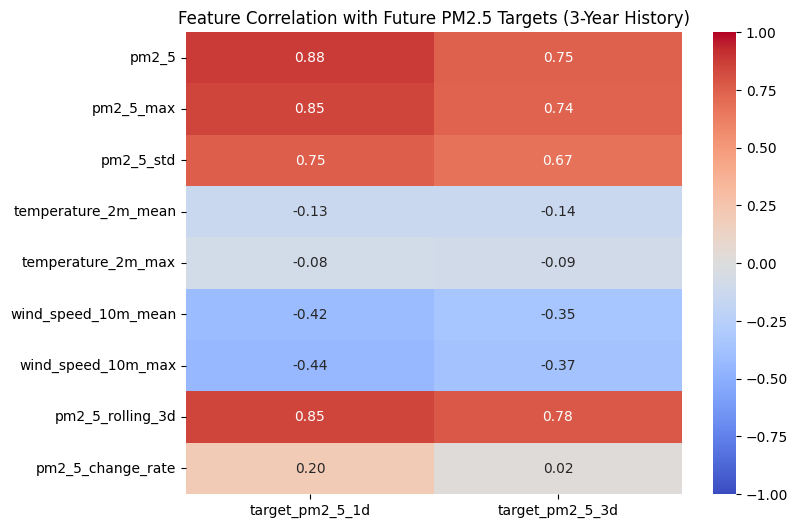

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns
import os
import hopsworks
from dotenv import load_dotenv

print("Linear Correlation with Day 1 and Day 3 Targets")

load_dotenv(os.path.abspath('../.env'))
project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai", 
    api_key_value=os.environ.get("HOPSWORKS_API_KEY")
)
fs = project.get_feature_store()

print("Downloading historical data from Hopsworks Version 6...")
fg = fs.get_feature_group("global_aqi_features", version=6)
history_df = fg.read()

eval_df = history_df[history_df['target_pm2_5_3d'] != -1.0].copy()

features_to_check = [
    'pm2_5', 'pm2_5_max', 'pm2_5_std', 
    'temperature_2m_mean', 'temperature_2m_max', 
    'wind_speed_10m_mean', 'wind_speed_10m_max',
    'pm2_5_rolling_3d', 'pm2_5_change_rate',
    'target_pm2_5_1d', 'target_pm2_5_3d'
]

corr_matrix = eval_df[features_to_check].corr()

target_corr = corr_matrix[['target_pm2_5_1d', 'target_pm2_5_3d']].drop(['target_pm2_5_1d', 'target_pm2_5_3d'])

plt.figure(figsize=(8, 6))
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Feature Correlation with Future PM2.5 Targets (3-Year History)")
plt.show()

## Non-Linear Predictive Power
A bar chart ranking features by their Mutual Information scores, indicating their true predictive value for complex tree-based models like LightGBM and XGBoost

EVIDENCE 2: Mutual Information Scores (Information Theory)
This proves which features provide the most predictive power for complex Tree models like LightGBM.




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



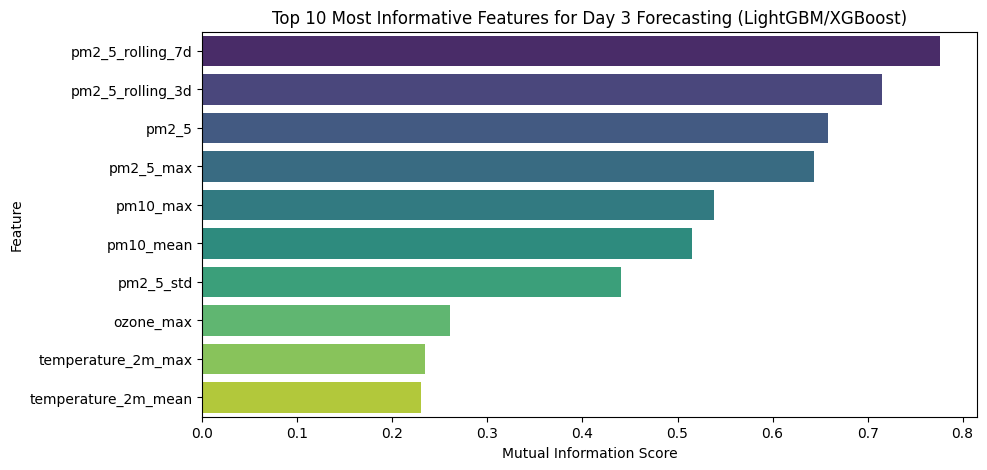

In [8]:

from sklearn.feature_selection import mutual_info_regression
import pandas as pd

print("Mutual Information Scores (Information Theory)")
print("This proves which features provide the most predictive power for complex Tree models like LightGBM.\n")

X = eval_df.drop(columns=['date', 'city', 'target_pm2_5_1d', 'target_pm2_5_2d', 'target_pm2_5_3d'])
y = eval_df['target_pm2_5_3d']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='MI_Score', y='Feature', data=mi_df.head(10), palette='viridis')
plt.title("Top 10 Most Informative Features for Day 3 Forecasting (LightGBM/XGBoost)")
plt.xlabel("Mutual Information Score")
plt.show()



## The Problem with Averages
A time-series plot comparing the flat daily average against the daily maximum pollution levels to illustrate the "hidden spike" phenomenon. This visually proves exactly why the model requires maximum and standard deviation metrics to accurately predict severe, volatile air quality events.

EVIDENCE 3: The 'Hidden Spike' Phenomenon
Proving why pm2_5 (mean) is insufficient, and why pm2_5_max was engineered.



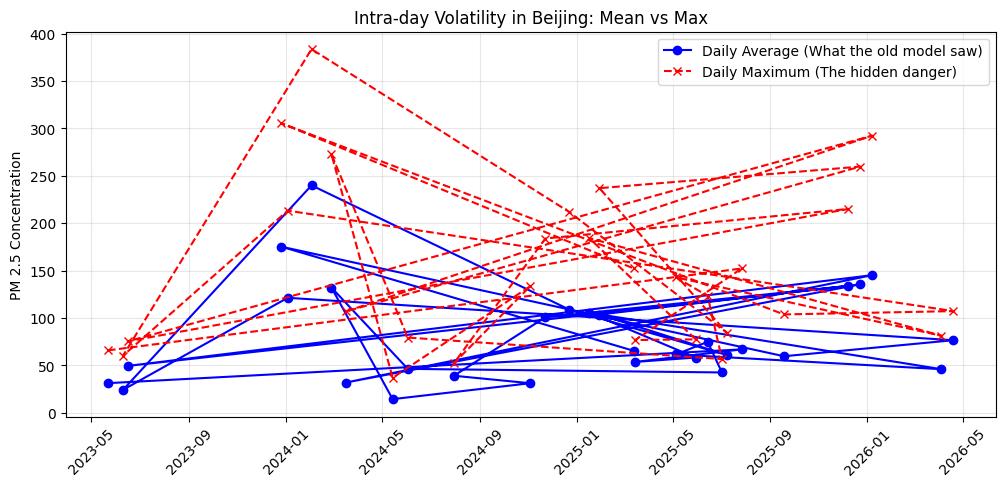

In [9]:

print("EVIDENCE 3: The 'Hidden Spike' Phenomenon")
print("Proving why pm2_5 (mean) is insufficient, and why pm2_5_max was engineered.\n")

hidden_spike_days = eval_df[(eval_df['pm2_5'] < 50) & (eval_df['pm2_5_max'] > 100)]

if not hidden_spike_days.empty:
    sample_city = hidden_spike_days.iloc[0]['city']
    
    plot_df = eval_df[eval_df['city'] == sample_city].head(30)
    
    plt.figure(figsize=(12, 5))
    plt.plot(plot_df['date'], plot_df['pm2_5'], label='Daily Average (What the old model saw)', marker='o', color='blue')
    plt.plot(plot_df['date'], plot_df['pm2_5_max'], label='Daily Maximum (The hidden danger)', marker='x', color='red', linestyle='--')
    
    plt.title(f"Intra-day Volatility in {sample_city.capitalize()}: Mean vs Max")
    plt.ylabel("PM 2.5 Concentration")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No extreme hidden spikes found in this current temporal slice.")


## Seasonality and Human Behavioral Patterns
Boxplots demonstrating how PM2.5 levels fluctuate based on the month (capturing weather seasonality like winter inversions) and the day of the week (capturing human industrial/traffic patterns). This justifies the inclusion of datetime-derived features.


## boxplot looks has a U-shape, it proves pollution is worse in winters
## 'day_of_week' shows dips on 5 and 6 (Saturday/Sunday), it proves the model needs to know when the weekend is to account for lower traffic/factory output.

2026-05-09 00:05:03,333 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 00:05:03,370 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



2026-05-09 00:05:03,551 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-09 00:05:03,569 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



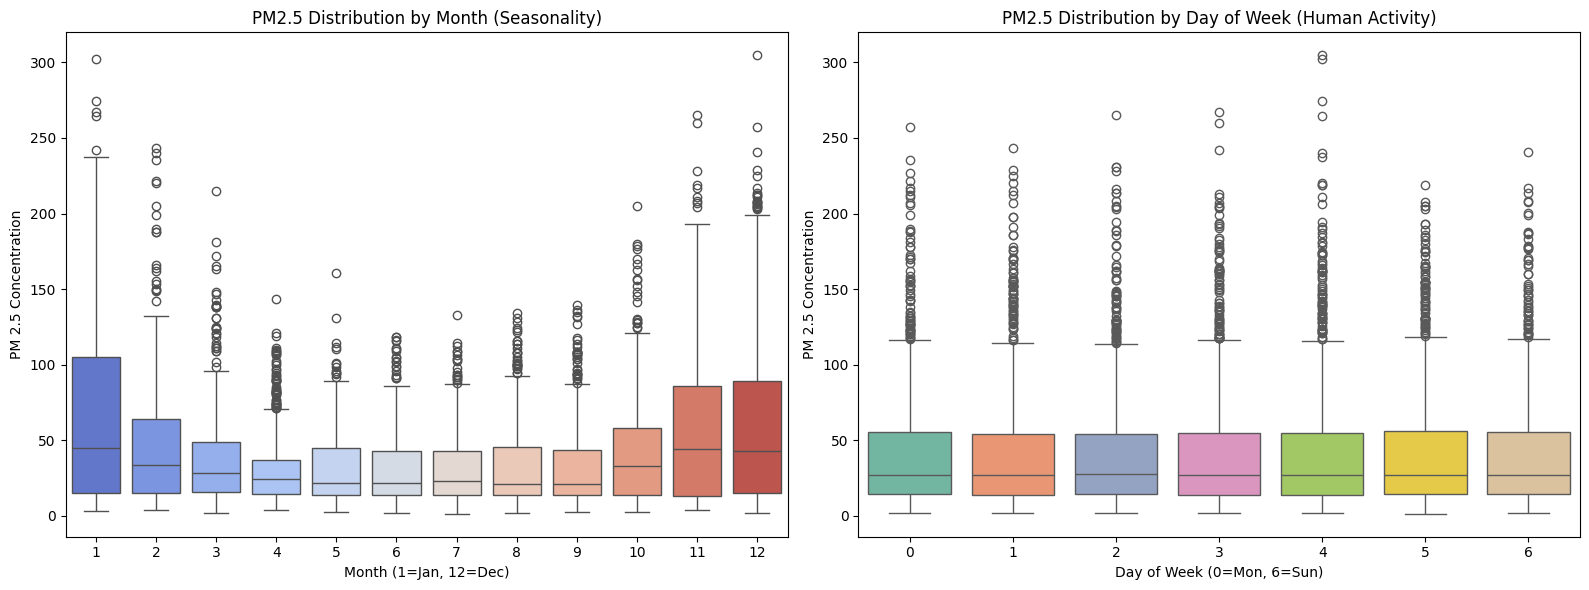

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(x='month', y='pm2_5', data=eval_df, ax=axes[0], palette='coolwarm')
axes[0].set_title("PM2.5 Distribution by Month (Seasonality)")
axes[0].set_xlabel("Month (1=Jan, 12=Dec)")
axes[0].set_ylabel("PM 2.5 Concentration")

sns.boxplot(x='day_of_week', y='pm2_5', data=eval_df, ax=axes[1], palette='Set2')
axes[1].set_title("PM2.5 Distribution by Day of Week (Human Activity)")
axes[1].set_xlabel("Day of Week (0=Mon, 6=Sun)")
axes[1].set_ylabel("PM 2.5 Concentration")

plt.tight_layout()
plt.show()



## Trend Extraction via Rolling Averages
A time-series smoothing visualization that proves why raw daily data is too noisy for long-term forecasting. By engineering a 7-day rolling average, we provide the model with a stable "baseline memory" of pollution accumulation.

# Result: 
# The raw values fluctuate greatly; those values, as it is, will affect the model adversely 
# So we use rolling averages to give the model a clean "macro" view of whether pollution is generally rising or falling over the week.

EVIDENCE 5: Proving why 'pm2_5_rolling_7d' is necessary for trend extraction



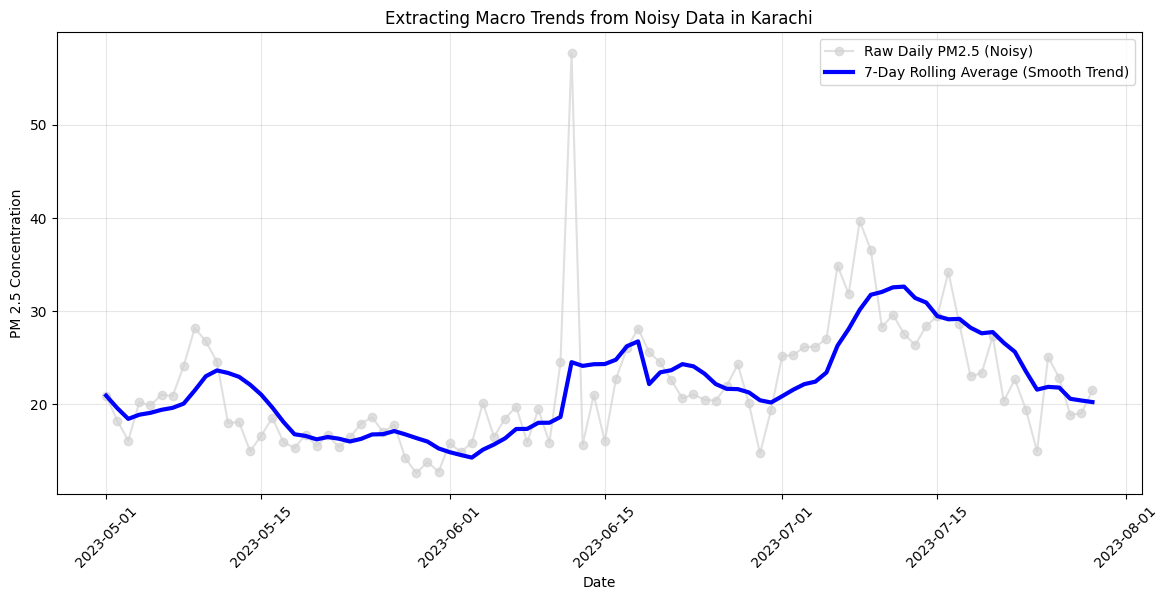

In [13]:
sample_city = eval_df['city'].unique()[0]
plot_df = eval_df[eval_df['city'] == sample_city].sort_values('date').head(90)

plt.figure(figsize=(14, 6))

plt.plot(plot_df['date'], plot_df['pm2_5'], label='Raw Daily PM2.5 (Noisy)', color='lightgrey', marker='o', alpha=0.7)

plt.plot(plot_df['date'], plot_df['pm2_5_rolling_7d'], label='7-Day Rolling Average (Smooth Trend)', color='blue', linewidth=3)

plt.title(f"Extracting Macro Trends from Noisy Data in {sample_city.capitalize()}")
plt.xlabel("Date")
plt.ylabel("PM 2.5 Concentration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()
